In [13]:
#Library imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Datasets imports
space_missions = pd.read_csv("re_worked/final/space_mission_dataset.csv")
movies = pd.read_csv("re_worked/movies_dataset.csv")

In [14]:
#Additional cleaning that I missed

#Converting both sets' date columns to datetime
space_missions['date'] = pd.to_datetime(space_missions['date'], format = "%d/%m/%Y")
movies['release_date'] = pd.to_datetime(movies['release_date'])

Notes from the below three visuals (space missions data)

Firstly, my reliable data ends in 2023. My dataset is incomplete for 2024, so maybe it would be best to leave that year out.

Secondly, from around 1964 until 1990 the number of missions remained above 100 year. The 1960's saw the biggest leap in mission launches (at the end of the space race, when Kenedy wanted to put a man on the moon, before the end of the decade). Something happened in the 90's or just before the decade, which made the space efforts begin to drop slowly, but steadily. 2000 - 2005 the number of space launches were almost at the same level as in 1961 (was there another focus? did space agencies lack funds or vision?). By 2009 the number of mission launches had begun to climb slowly. 

A huge difference can be seen when comparing 1960-1990 with 1991-2017. Something happened around 2020 which made mission launches to skyrocket in number(geopolitical shift? a response to China's space ambitions? the begining of a new space race?).

I wanted to see which country had the most launch missions and was suprised to find Kazakhstan among the top 3. After some research, I found out that the Baikonur Cosmodrome is located is Kazahstan, which was and still is a central hub for Russia's space missions. Because of that, I decided to group the two countries toghether in future charts. I grouped the launches by country and decade (filtering to have only the top 3 countries) and saw that after 'winning' the space race, the US significantly reduced it's launch missions, while Russia doubled theirs. It seems that from the 70s (around) onwards, China began it's own space program, which developed over the decades, reaching the US and Russia's output by the 2010s. That's around when the US began mounting more missions again.

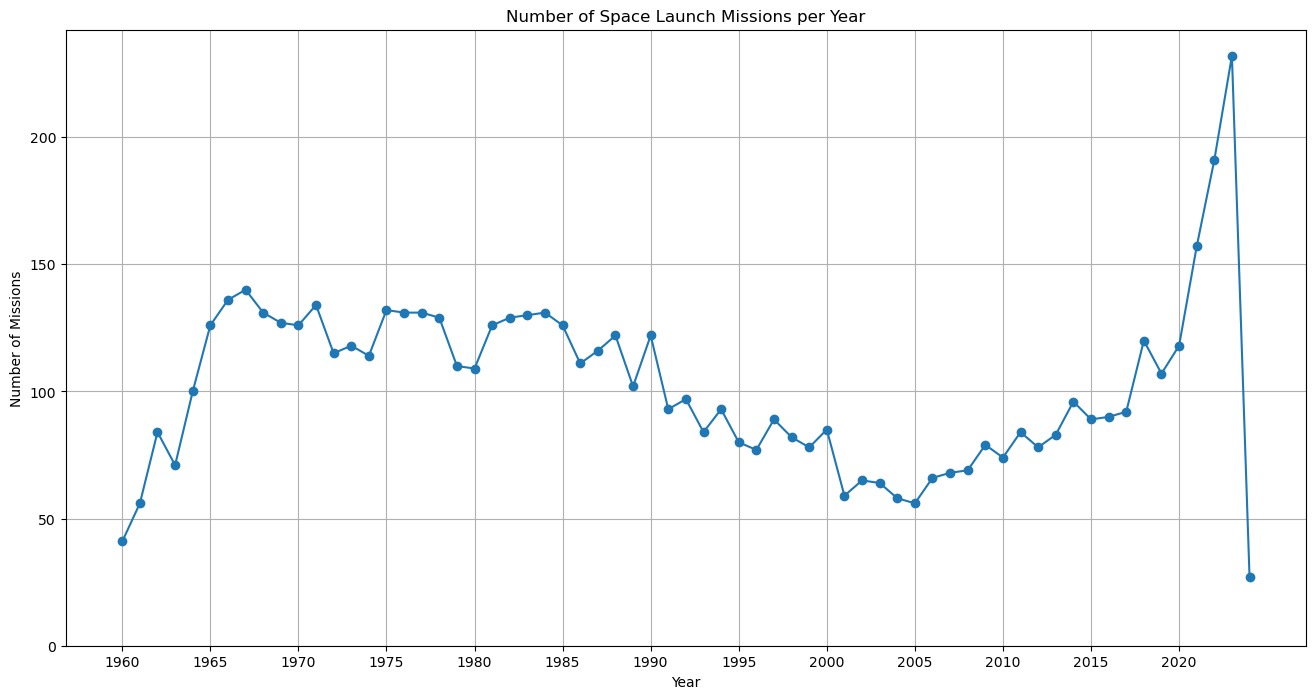

In [27]:
#Creating a number of launches per year visual

#Creating an extra column with just the year, so I can group by it
space_missions['year'] = space_missions['date'].dt.year

#Counting the missions per year and grouping them
missions_per_year = space_missions.groupby('year').size()

#Visualizing the number of space missions per year
plt.figure(figsize = (16,8))
plt.plot(missions_per_year.index, missions_per_year.values, marker='o')

#Increasing the number of x ticks
plt.xticks(range(missions_per_year.index.min(),
                 missions_per_year.index.max() + 1,
                 5))

#Increasing the number of y ticks
plt.yticks(range(0,
                 missions_per_year.values.max() + 1,
                 50))

#Populating the chart
plt.title("Number of Space Launch Missions per Year")

plt.xlabel("Year")
plt.ylabel("Number of Missions")
plt.grid(True)

plt.show()

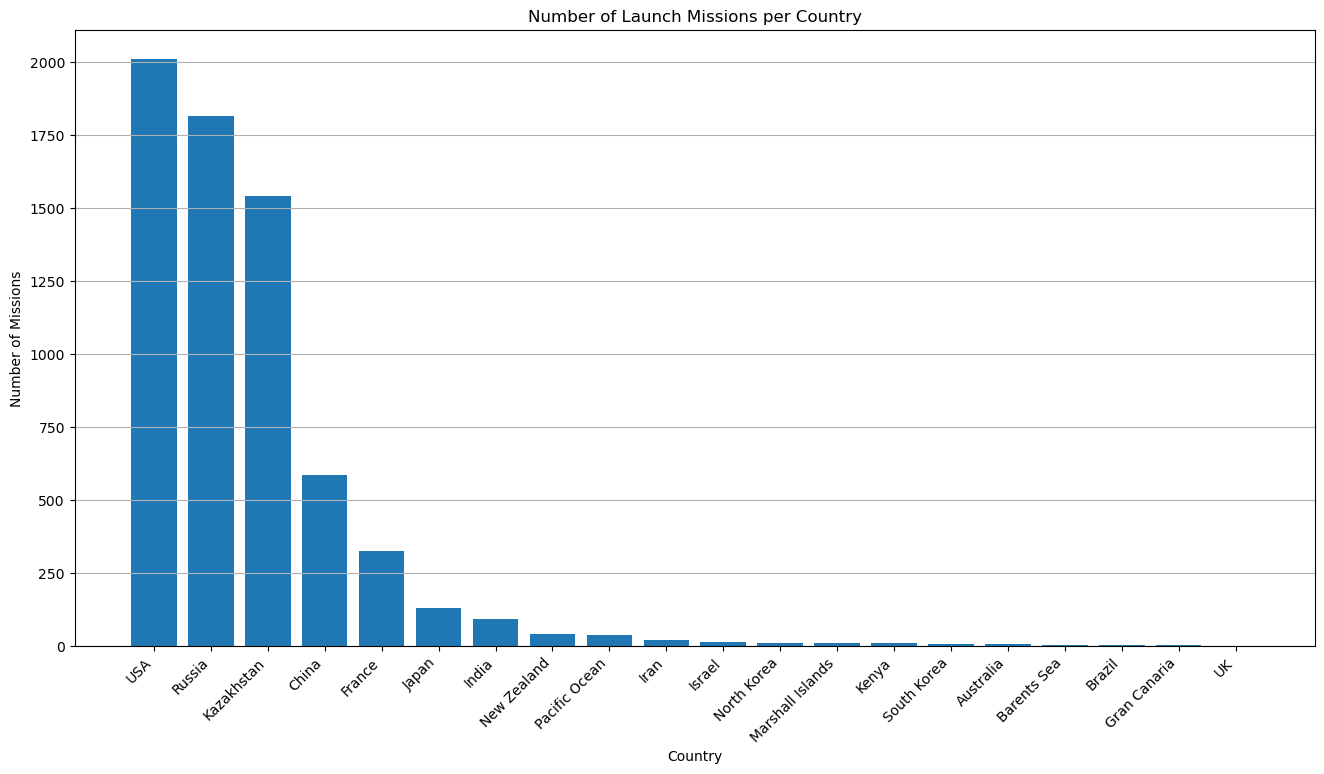

In [17]:
#Ploting the number of launch missions by country - here I notices Kazakhstan

#Counts missions per country
missions_per_country = space_missions['launch_location'].value_counts()

#Visualizes the result 
plt.figure(figsize=(16,8))
plt.bar(missions_per_country.index, missions_per_country.values)

#Populating the chart
plt.title("Number of Launch Missions per Country")
plt.xlabel("Country")
plt.ylabel("Number of Missions")

#Rotates lables and prevents overlap
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.show()

<Figure size 1800x900 with 0 Axes>

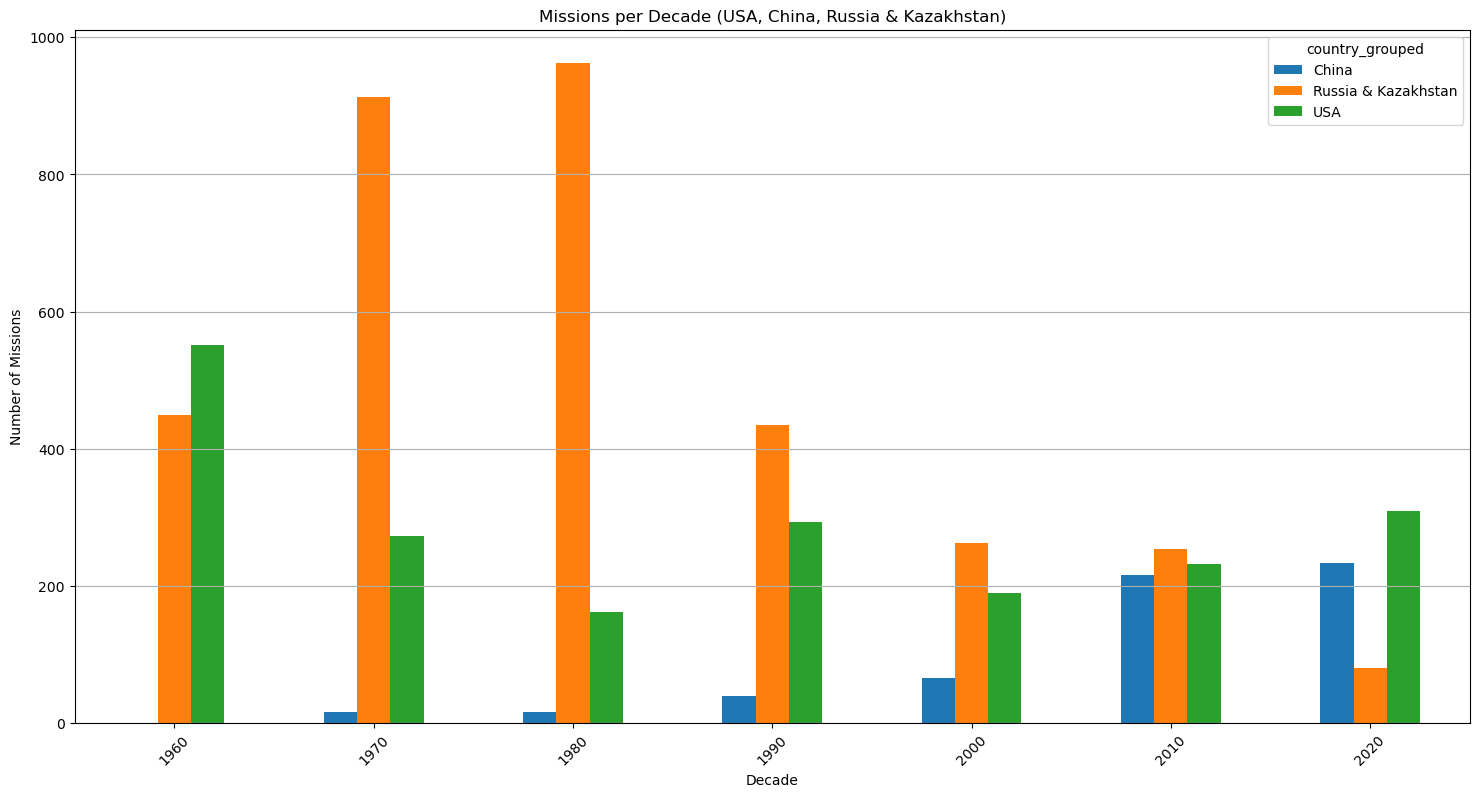

In [22]:
#Group the launch mission by country and decade; Russia and Kazakhstan are grouped
#Creates a decade column
space_missions["decade"] = (space_missions["date"].dt.year // 10) * 10


#Merging Russia and Kazakhstan
space_missions.loc[space_missions["launch_location"] == "Russia", "launch_location"] = "Russia & Kazakhstan"
space_missions.loc[space_missions["launch_location"] == "Kazakhstan", "launch_location"] = "Russia & Kazakhstan"

#Create a group to filter and group by
space_missions["country_grouped"] = space_missions["launch_location"]

#Filtering the set to only include the top 3 countries with the most launches
top_3 = ["USA", "China", "Russia & Kazakhstan"]
missions = space_missions[space_missions["country_grouped"].isin(top_3)]

#Grouping by decade and country
counts_decade_country = missions.groupby(["decade", "country_grouped"]).size()

#Creating a table, using the grouped data
counts_decade_country = counts_decade_country.unstack(fill_value=0)

#Plotting the data
plt.figure(figsize=(18,9))
counts_decade_country.plot(kind="bar", figsize=(18,9))

#Populating the chart
plt.title("Missions per Decade (USA, China, Russia & Kazakhstan)")

plt.xlabel("Decade")
plt.ylabel("Number of Missions")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

I need to limit the movies to 2023, so as to keep with the launch missions dataset. Also, there isn't enough information for 2025.


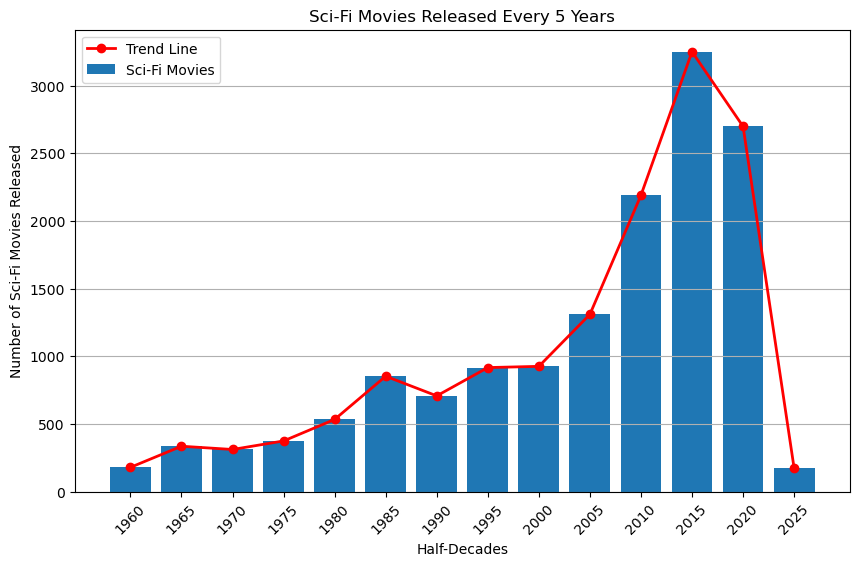

In [32]:
#Create a five year period column to group by
movies["five_year"] = (movies["release_date"].dt.year // 5) * 5

#Search for SciFi movies only and count them
sci_fi = movies[movies["genres"].str.contains("Science Fiction")]
sci_fi_count = sci_fi.groupby("five_year").size()

#Plotting the visual
plt.figure(figsize=(10,6))

#Creating the bar chart and the line chart
plt.bar(sci_fi_count.index, sci_fi_count.values, width=4, label="Sci-Fi Movies")
plt.plot(sci_fi_count.index, sci_fi_count.values, color="red", marker="o", linewidth=2, label="Trend Line")

#Populating the visual
plt.title("Sci‑Fi Movies Released Every 5 Years")

plt.xlabel("Half-Decades")
plt.ylabel("Number of Sci‑Fi Movies Released")
plt.xticks(sci_fi_count.index, rotation=45)

plt.grid(axis="y")
plt.legend()

plt.show()

There is an overall upward trend. 1985, 1995 and 200 had a similar number of scifi movies produces. The period between 2005 - 2015 saw a huge growth in the number of scifi films released, compared to previous time periods.

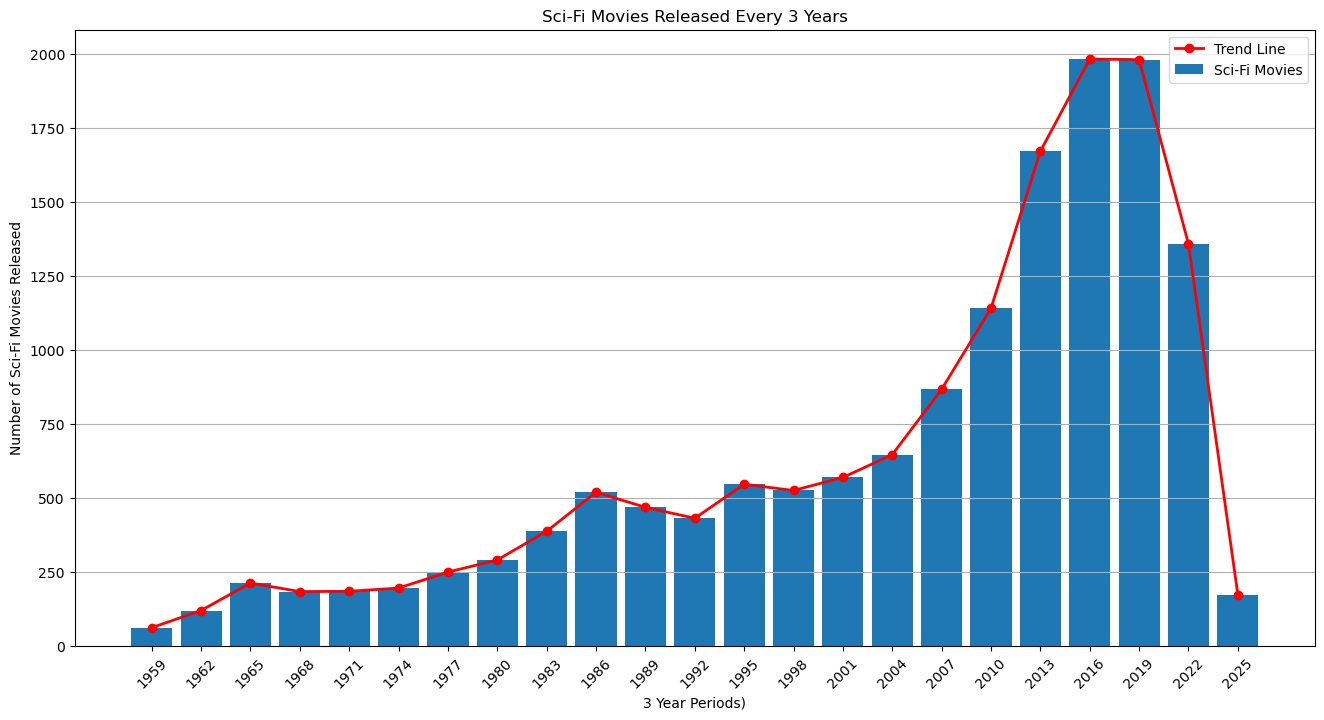

In [31]:
#Create a three year period column to group by
movies["three_year"] = (movies["release_date"].dt.year // 3) * 3

#Search for SciFi movies only and count them
sci_fi = movies[movies["genres"].str.contains("Science Fiction")]
sci_fi_counts = sci_fi.groupby("three_year").size()

#Plotting the visual
plt.figure(figsize=(16,8))

#reating the bar chart and line charts
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=2.5, label="Sci-Fi Movies")
plt.plot(sci_fi_counts.index, sci_fi_counts.values, color="red", marker="o", linewidth=2, label="Trend Line")

#Populating the visual
plt.title("Sci‑Fi Movies Released Every 3 Years")

plt.xlabel("3 Year Periods)")
plt.ylabel("Number of Sci‑Fi Movies Released")

plt.xticks(sci_fi_counts.index, rotation=45)

plt.grid(axis="y")
plt.legend()

plt.show()

The above mentioned trend is seen even clearer here. The period betweem 1960 - 1986 saw a generel increase (with the spike in the 60s being around 1965). Between 1986 - 1995 there's was a slight decrease, but the numbers were never as low as in previous years/ 3 year periods. From around 2004 onwards - exponential increase in scifi movies (better technology? shifting cultural view or interest?)

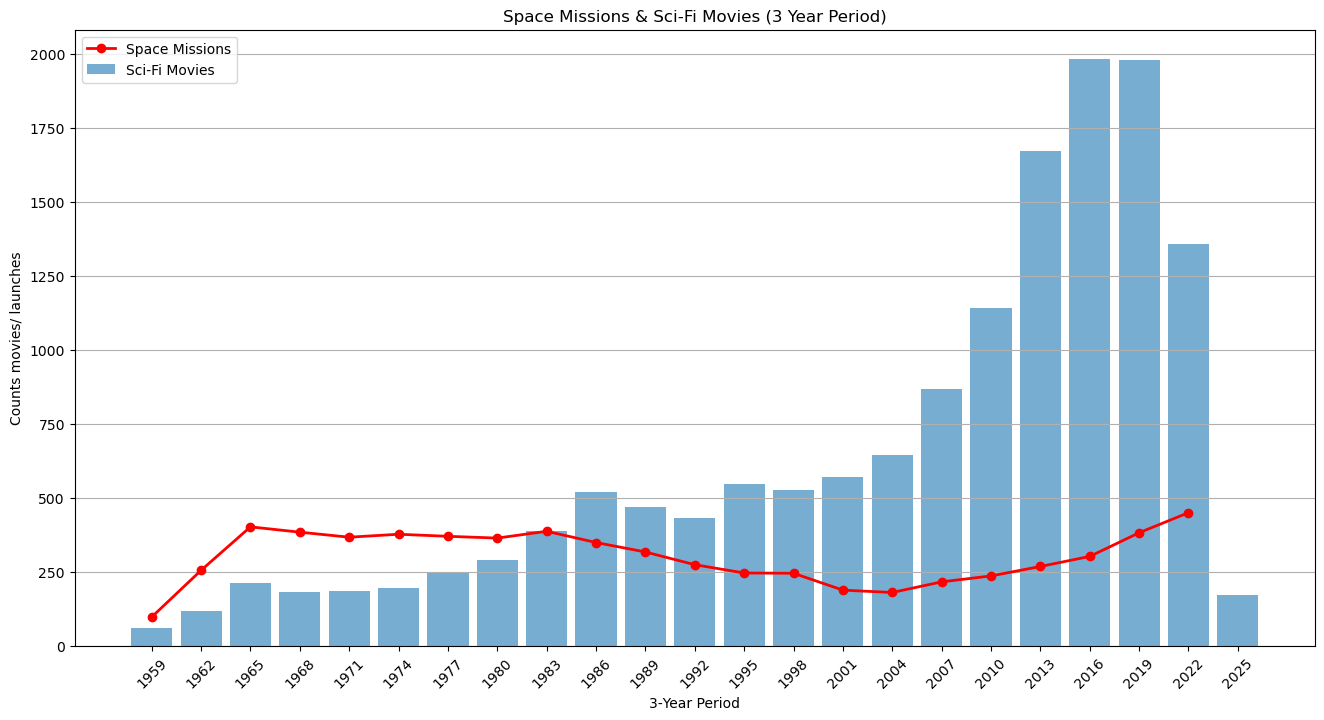

In [47]:
#Creates a three year period column to group and filter by
space_missions["three_year"] = (space_missions["date"].dt.year // 3) * 3

#Counts the missions per 3 years
missions_3yr = space_missions.groupby("three_year").size()

#Create a 3‑year period column for movies
movies["three_year"] = (movies["release_date"].dt.year // 3) * 3

# Filters scifi movies and groups the,
sci_fi = movies[movies["genres"].str.contains("Science Fiction")]
sci_fi_counts = sci_fi.groupby("three_year").size()

#Creating the figure
plt.figure(figsize=(16,8))

#Visualizing SciFi movies as bars and the missions as a linechart
plt.bar(sci_fi_counts.index, sci_fi_counts.values, width=2.5, label="Sci‑Fi Movies", alpha=0.6)
plt.plot(missions_3yr.index, missions_3yr.values, color="red", marker="o", linewidth=2, label="Space Missions")

#Populating the visuals
plt.title("Space Missions & Sci‑Fi Movies (3 Year Period)")
plt.xlabel("3‑Year Period")
plt.ylabel("Counts movies/ launches")

plt.xticks(sorted(set(list(missions_3yr.index) + list(sci_fi_counts.index))), rotation=45)
plt.grid(axis="y")
plt.legend()

plt.show()

From the above graph I wasn't able to observe anything interesting happening. Right now I am examining if a space launch would effect the number of scifi films released (2-3 years after a lauch). I thought the movement of the film and mission numbers was in a unison almost, betweem 1960-1983. But then, after that period I couldn't observe any realtions. It looks like the number of scifi movies was increasing, regardles of the number of commercial space launches. Maybe I need to look more granuarly at the different time periods?

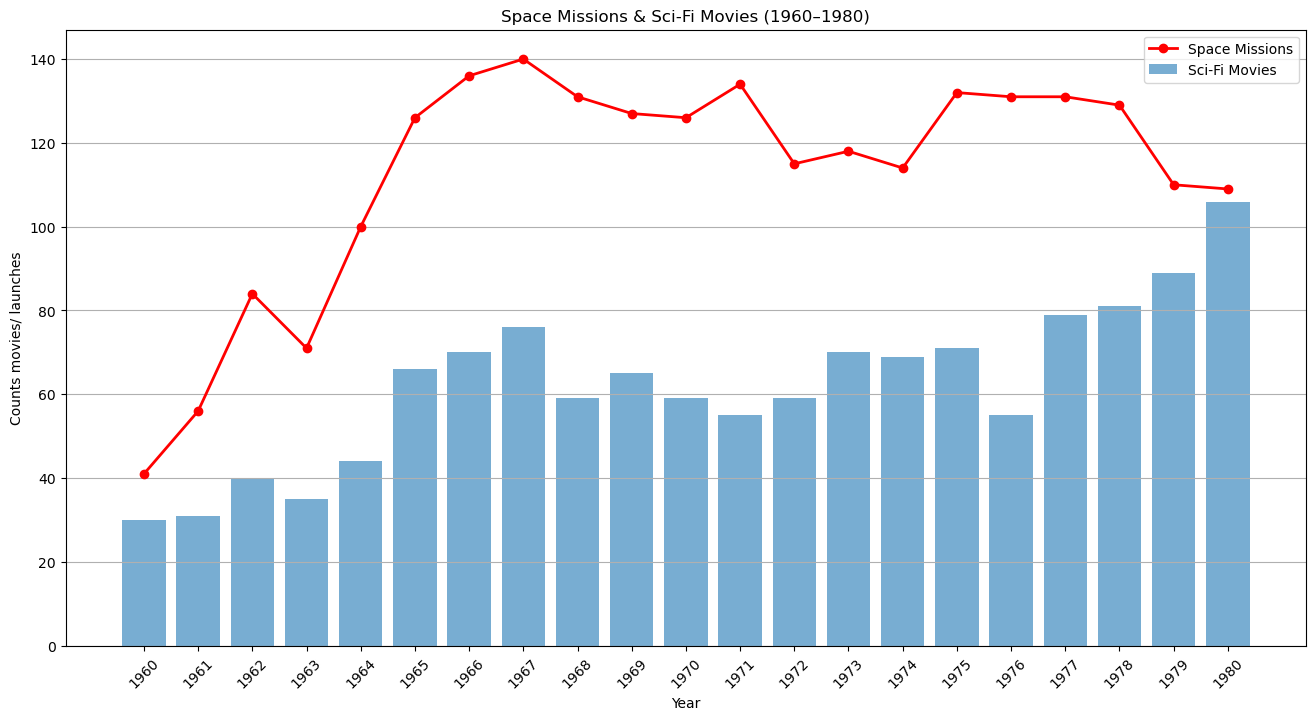

In [48]:
#Creates a new column - year - for both sets' dates
space_missions["year"] = space_missions["date"].dt.year
movies["year"] = movies["release_date"].dt.year

#Filtering for the period 1960 - 1980 - missions and films
missions_60s_80s = space_missions[(space_missions["year"] >= 1960) & (space_missions["year"] <= 1980)]
movies_60s_80s = movies[(movies["year"] >= 1960) & (movies["year"] <= 1980)]

#Filtering for the period 1980 - 2000 - missions and films
missions_80s_00s = space_missions[(space_missions["year"] >= 1980) & (space_missions["year"] <= 2000)]
movies_80s_00s = movies[(movies["year"] >= 1980) & (movies["year"] <= 2000)]

#Filtering for scifi movies for the above mentioned periods
sci_fi_60s_80s = movies_60_80[movies_60_80["genres"].str.contains("Science Fiction")]
sci_fi_80s_00s = movies_80_00[movies_80_00["genres"].str.contains("Science Fiction")]

#Groups the timeframes by year and counts
missions_60s_80s_year = missions_60_80.groupby("year").size()
sci_fi_60s_80s_year = sci_fi_60_80.groupby("year").size()

missions_80s_00s_year = missions_80_00.groupby("year").size()
sci_fi_80s_00s_year = sci_fi_80_00.groupby("year").size()

#Plotting the visual
plt.figure(figsize=(16,8))

#Plotting the bar and line charts
plt.bar(sci_fi_60_80_year.index, sci_fi_60_80_year.values, width=0.8, alpha=0.6, label="Sci‑Fi Movies")
plt.plot(missions_60_80_year.index, missions_60_80_year.values, color="red", marker="o", linewidth=2, label="Space Missions")

#Populating the visual (60s-80s)
plt.title("Space Missions & Sci‑Fi Movies (1960–1980)")

plt.xlabel("Year")
plt.ylabel("Counts movies/ launches")

plt.xticks(sci_fi_60_80_year.index, rotation=45)
plt.grid(axis="y")
plt.legend()

plt.show()

Taking a more graniular approach, I still couldn't make out if there was an observable correlation. Again, until 1968, both outputs seem to move in unison. There are moments in both graphs where one seems to follow the other and moments when, if I look for changes in movies and compare them with lauch frequency 2-3 years ago, my theory fits. There are moments of uncorelated changes as well however. As I am looking to compare two timelines at different points and searching for a pattern in them, I chose to do a lag analysis.  

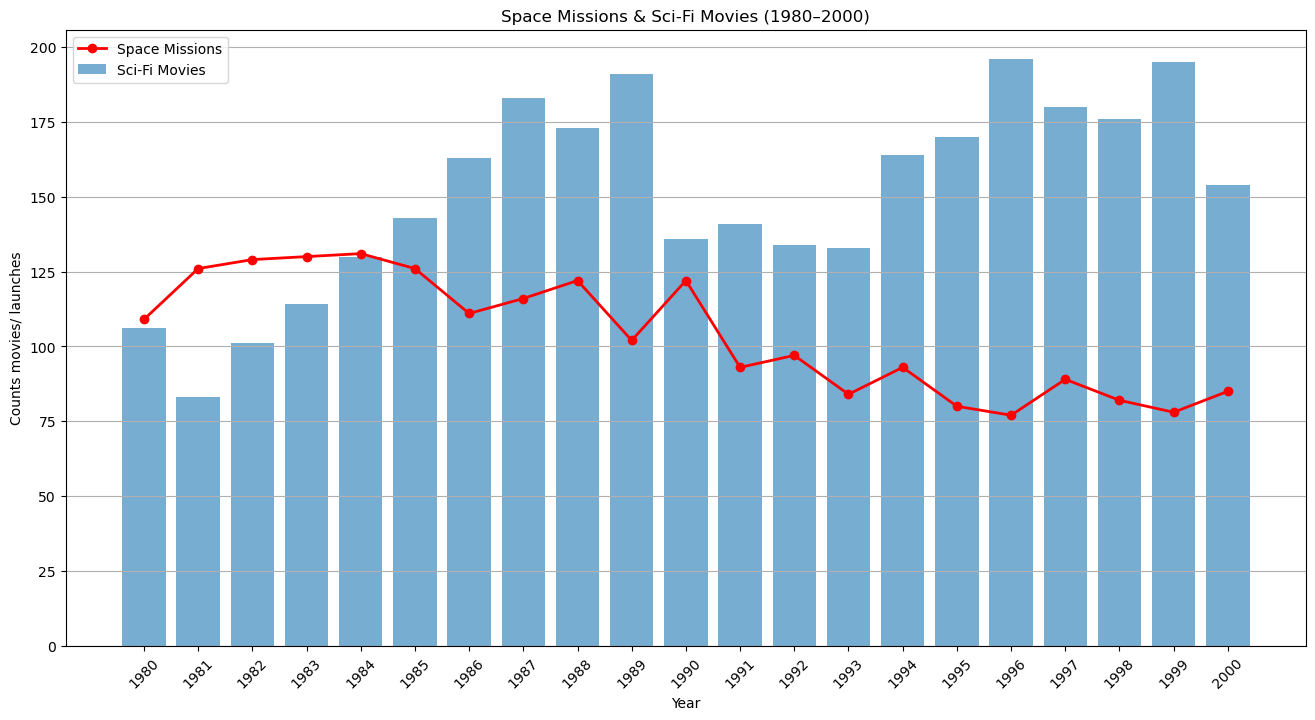

In [49]:
#Plotting the visual (80s-00s)
plt.figure(figsize=(16,8))

#Plotting the bar and line charts
plt.bar(sci_fi_80_00_year.index, sci_fi_80_00_year.values, width=0.8, alpha=0.6, label="Sci‑Fi Movies")
plt.plot(missions_80_00_year.index, missions_80_00_year.values, color="red", marker="o", linewidth=2, label="Space Missions")

#Populating the visual
plt.title("Space Missions & Sci‑Fi Movies (1980–2000)")

plt.xlabel("Year")
plt.ylabel("Counts movies/ launches")

plt.xticks(sci_fi_80_00_year.index, rotation=45)
plt.grid(axis="y")
plt.legend()

plt.show()

In [54]:
#Converting to datetime values as earlier iterations of the code kept giving me an error message
space_missions["year"] = pd.to_datetime(space_missions["date"], dayfirst=True).dt.year
movies["year"] = pd.to_datetime(sci_fi["release_date"]).dt.year

#Shifting the scifi movie values (creating lag series) 
sci_fi_lag1 = sci_fi_year.shift(-1)
sci_fi_lag2 = sci_fi_year.shift(-2)
sci_fi_lag3 = sci_fi_year.shift(-3)
sci_fi_lag4 = sci_fi_year.shift(-4)

#Calculating the correlation for each lag
corr_0 = missions_year.corr(sci_fi_year)
corr_1 = missions_year.corr(sci_fi_lag1)
corr_2 = missions_year.corr(sci_fi_lag2)
corr_3 = missions_year.corr(sci_fi_lag3)
corr_4 = missions_year.corr(sci_fi_lag4)

#Print results
print("Lag 0:", corr_0)
print("Lag 1:", corr_1)
print("Lag 2:", corr_2)
print("Lag 3:", corr_3)
print("Lag 4:", corr_4)

Lag 0: 0.11128026419386552
Lag 1: -0.025444477781361503
Lag 2: -0.1345388327805879
Lag 3: -0.30116565820136565
Lag 4: -0.37208195321659515


No significant correlation found.